In [2]:
source("../DBDA2Eprograms/DBDA2E-utilities.R")


*********************************************************************
Kruschke, J. K. (2015). Doing Bayesian Data Analysis, Second Edition:
A Tutorial with R, JAGS, and Stan. Academic Press / Elsevier.
*********************************************************************



In [3]:
#------------------------------------------------------------------------------
# THE DATA.

# Randomly generated fictitious data.
# For each subject, specify the condition s/he was in,
# the number of trials s/he experienced, and the number correct.
npg = 20  # number of subjects per group
ntrl = 20 # number of trials per subject
CondOfSubj = c( rep(1,npg) , rep(2,npg) , rep(3,npg) , rep(4,npg) )
nTrlOfSubj = rep( ntrl , 4*npg )
set.seed(47405)
condMeans = c(.40,.50,.51,.52)
nCorrOfSubj = c( rbinom(npg,ntrl,condMeans[1]) , rbinom(npg,ntrl,condMeans[2]) ,
                 rbinom(npg,ntrl,condMeans[3]) , rbinom(npg,ntrl,condMeans[4]) )
nCond = length(unique(CondOfSubj))
nSubj = length(CondOfSubj)
# jitter the data to be as close as possible to desired condition means:
for ( cIdx in 1:nCond ) {
  nToAdd = round(condMeans[cIdx]*npg*ntrl)-sum(nCorrOfSubj[CondOfSubj==cIdx])
  if ( nToAdd > 0 ) {
    for ( i in 1:nToAdd ) {
      thisNcorr = ntrl
      while ( thisNcorr == ntrl ) {
        randSubjIdx = sample(which(CondOfSubj==cIdx),size=1)
        thisNcorr = nCorrOfSubj[randSubjIdx]
      }
      nCorrOfSubj[randSubjIdx] = nCorrOfSubj[randSubjIdx]+1
    }
  } 
  if ( nToAdd < 0 ) {
    for ( i in 1:abs(nToAdd) ) {
      thisNcorr = 0
      while ( thisNcorr == 0 ) {
        randSubjIdx = sample(which(CondOfSubj==cIdx),size=1)
        thisNcorr = nCorrOfSubj[randSubjIdx]
      }
      nCorrOfSubj[randSubjIdx] = nCorrOfSubj[randSubjIdx]-1
    }
  }
}

nCond = 2
CondOfSubj[CondOfSubj == 3] = 2
CondOfSubj[CondOfSubj == 4] = 2

show( aggregate( nCorrOfSubj , by=list(CondOfSubj) , FUN=mean ) / ntrl )

# Package the data:
dataList = list(
  nCond = nCond ,
  nSubj = nSubj ,
  CondOfSubj = CondOfSubj ,
  nTrlOfSubj = nTrlOfSubj ,
  nCorrOfSubj = nCorrOfSubj
)


  Group.1    x
1    0.05 0.40
2    0.10 0.51


In [4]:
#------------------------------------------------------------------------------
# THE MODEL.

modelString = "
model {
  for ( s in 1:nSubj ) {
    nCorrOfSubj[s] ~ dbin( theta[s] , nTrlOfSubj[s] )
    theta[s] ~ dbeta( aBeta[CondOfSubj[s]] , bBeta[CondOfSubj[s]] ) 
  }

#   for ( j in 1:nCond ) {
#     # Use omega[j] for model index 1, omega0 for model index 2:
#     aBeta[j] <-       ( equals(mdlIdx,1)*omega[j] 
#                       + equals(mdlIdx,2)*omega0  )   * (kappa[j]-2)+1
#     bBeta[j] <- ( 1 - ( equals(mdlIdx,1)*omega[j] 
#                       + equals(mdlIdx,2)*omega0  ) ) * (kappa[j]-2)+1
#   }
#   for ( j in 1:2 ) {
#     omega[j] ~ dbeta( a[j,mdlIdx] , b[j,mdlIdx] )
#   }
#   omega[3] <- omega[2]
#   omega[4] <- omega[2]

  for ( j in 1:nCond ) {
    # Use omega[j] for model index 1, omega0 for model index 2:
    aBeta[j] <-       ( equals(mdlIdx,1)*omega[j] 
                      + equals(mdlIdx,2)*omega0  )   * (kappa[j]-2)+1
    bBeta[j] <- ( 1 - ( equals(mdlIdx,1)*omega[j] 
                      + equals(mdlIdx,2)*omega0  ) ) * (kappa[j]-2)+1
    omega[j] ~ dbeta( a[j,mdlIdx] , b[j,mdlIdx] )
  }

  omega0 ~ dbeta( a0[mdlIdx] , b0[mdlIdx] )
  for ( j in 1:nCond ) {
    kappa[j] <- kappaMinusTwo[j] + 2
    kappaMinusTwo[j] ~ dgamma( 2.618 , 0.0809 ) # mode 20 , sd 20
  }
  # Constants for prior and pseudoprior:
  aP <- 1
  bP <- 1
  # a0[model] and b0[model]
  a0[1] <- .48*500       # pseudo
  b0[1] <- (1-.48)*500   # pseudo 
  a0[2] <- aP            # true
  b0[2] <- bP            # true
  # a[condition,model] and b[condition,model]
  a[1,1] <- aP           # true
  a[2,1] <- aP           # true
  a[3,1] <- aP           # true
  a[4,1] <- aP           # true
  b[1,1] <- bP           # true
  b[2,1] <- bP           # true
  b[3,1] <- bP           # true
  b[4,1] <- bP           # true
  a[1,2] <- .40*125      # pseudo
  a[2,2] <- .50*125      # pseudo
  a[3,2] <- .51*125      # pseudo
  a[4,2] <- .52*125      # pseudo
  b[1,2] <- (1-.40)*125  # pseudo
  b[2,2] <- (1-.50)*125  # pseudo
  b[3,2] <- (1-.51)*125  # pseudo
  b[4,2] <- (1-.52)*125  # pseudo
  # Prior on model index:
  mdlIdx ~ dcat( modelProb[] )
  modelProb[1] <- .5
  modelProb[2] <- .5
}
" # close quote for modelstring
writeLines( modelString , con="TEMPmodel.txt" )

In [5]:

#------------------------------------------------------------------------------
# INTIALIZE THE CHAINS.

# Let JAGS do it...

#------------------------------------------------------------------------------
# RUN THE CHAINS.

parameters = c("omega","kappa","omega0","theta","mdlIdx")
adaptSteps = 1000            # Number of steps to "tune" the samplers.
burnInSteps = 5000           # Number of steps to "burn-in" the samplers.
nChains = 3                  # Number of chains to run.
numSavedSteps=12000          # Total number of steps in chains to save.
thinSteps=20                 # Number of steps to "thin" (1=keep every step).

# nPerChain = ceiling( ( numSavedSteps * thinSteps ) / nChains ) # Steps per chain.
# # Create, initialize, and adapt the model:
# jagsModel = jags.model( "TEMPmodel.txt" , data=dataList , # inits=initsList , 
#                         n.chains=nChains , n.adapt=adaptSteps )
# # Burn-in:
# cat( "Burning in the MCMC chain...\n" )
# update( jagsModel , n.iter=burnInSteps )
# # The saved MCMC chain:
# cat( "Sampling final MCMC chain...\n" )
# codaSamples = coda.samples( jagsModel , variable.names=parameters , 
#                             n.iter=nPerChain , thin=thinSteps )

runJagsOut <- run.jags( method=c("rjags","parallel")[2] ,
                        model="TEMPmodel.txt" , 
                        monitor=parameters , 
                        data=dataList ,  
                        #inits=initsList , 
                        n.chains=nChains ,
                        adapt=adaptSteps ,
                        burnin=burnInSteps , 
                        sample=ceiling(numSavedSteps/nChains) ,
                        thin=thinSteps ,
                        summarise=FALSE ,
                        plots=FALSE )
codaSamples = as.mcmc.list( runJagsOut )
#------------------------------------------------------------------------------
# EXAMINE THE RESULTS.

Calling 3 simulations using the parallel method...
Following the progress of chain 1 (the program will wait for all chains
to finish before continuing):
Welcome to JAGS 4.3.2 on Tue Mar  3 16:38:10 2026
JAGS is free software and comes with ABSOLUTELY NO WARRANTY
Loading module: basemod: ok
Loading module: bugs: ok
. . Reading data file data.txt
. Compiling model graph
   Resolving undeclared variables
   Allocating nodes
Graph information:
   Observed stochastic nodes: 80
   Unobserved stochastic nodes: 86
   Total graph size: 380
. Reading parameter file inits1.txt
. Initializing model
. Adapting 1000
-------------------------------------------------| 1000
++++++++++++++++++++++++++++++++++++++++++++++++++ 100%
Adaptation successful
. Updating 5000
-------------------------------------------------| 5000
************************************************** 100%
. . . . . . Updating 80000
-------------------------------------------------| 80000
********************************************

 [1] "omega[1]"  "omega[2]"  "kappa[1]"  "kappa[2]"  "omega0"    "theta[1]" 
 [7] "theta[2]"  "theta[3]"  "theta[4]"  "theta[5]"  "theta[6]"  "theta[7]" 
[13] "theta[8]"  "theta[9]"  "theta[10]" "theta[11]" "theta[12]" "theta[13]"
[19] "theta[14]" "theta[15]" "theta[16]" "theta[17]" "theta[18]" "theta[19]"
[25] "theta[20]" "theta[21]" "theta[22]" "theta[23]" "theta[24]" "theta[25]"
[31] "theta[26]" "theta[27]" "theta[28]" "theta[29]" "theta[30]" "theta[31]"
[37] "theta[32]" "theta[33]" "theta[34]" "theta[35]" "theta[36]" "theta[37]"
[43] "theta[38]" "theta[39]" "theta[40]" "theta[41]" "theta[42]" "theta[43]"
[49] "theta[44]" "theta[45]" "theta[46]" "theta[47]" "theta[48]" "theta[49]"
[55] "theta[50]" "theta[51]" "theta[52]" "theta[53]" "theta[54]" "theta[55]"
[61] "theta[56]" "theta[57]" "theta[58]" "theta[59]" "theta[60]" "theta[61]"
[67] "theta[62]" "theta[63]" "theta[64]" "theta[65]" "theta[66]" "theta[67]"
[73] "theta[68]" "theta[69]" "theta[70]" "theta[71]" "theta[72]" "theta[73]"

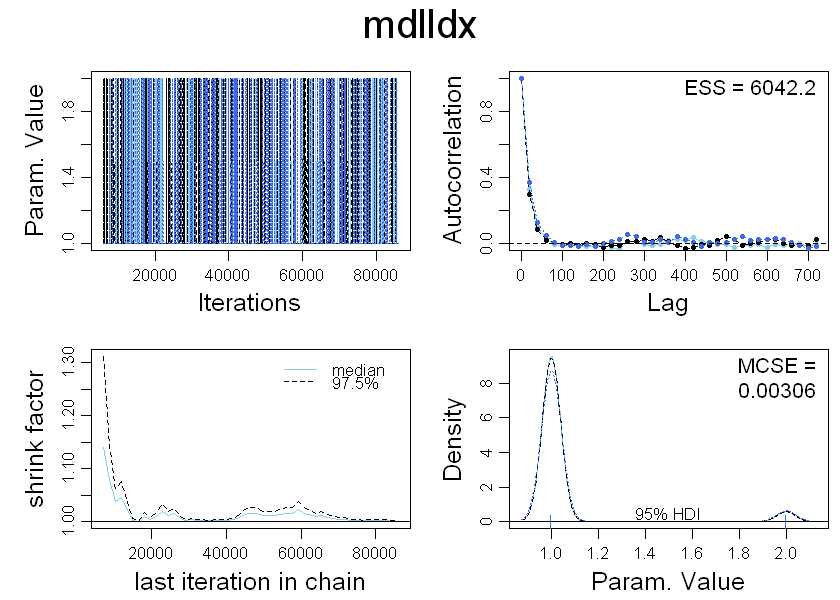

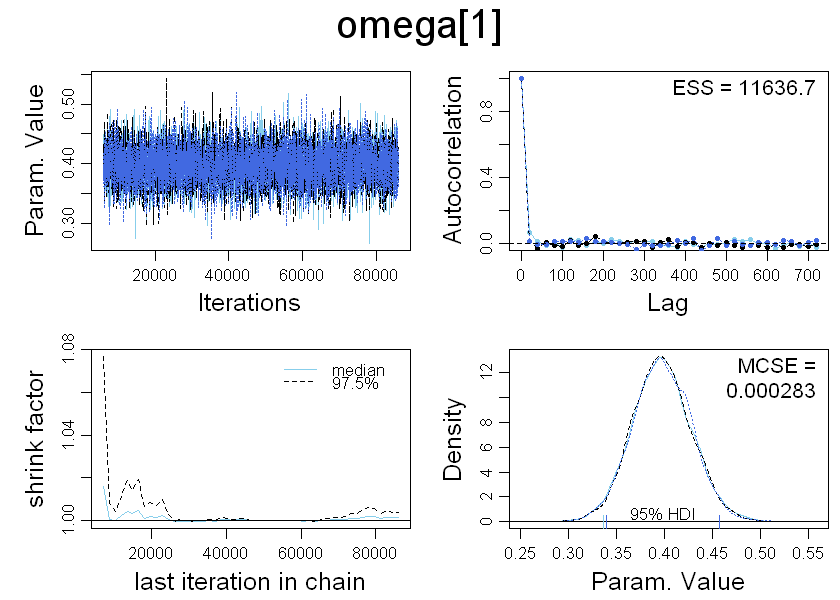

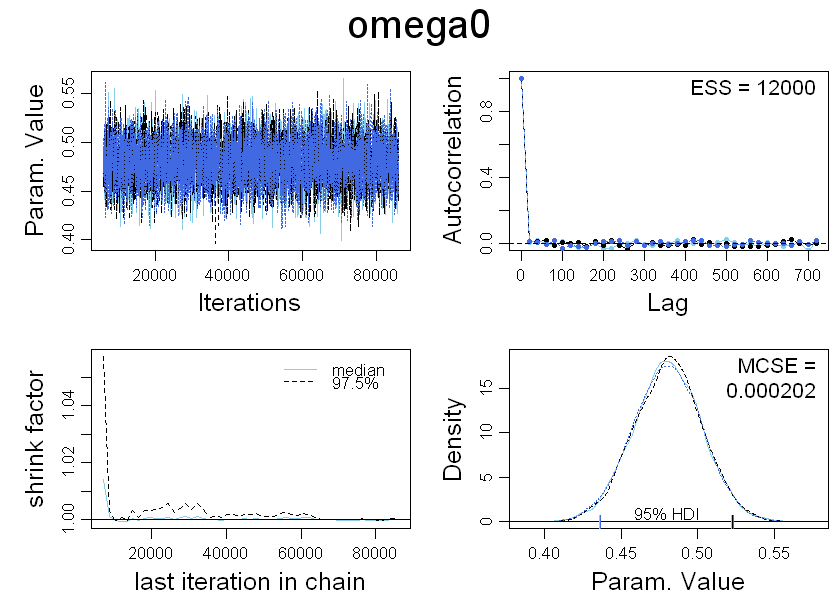

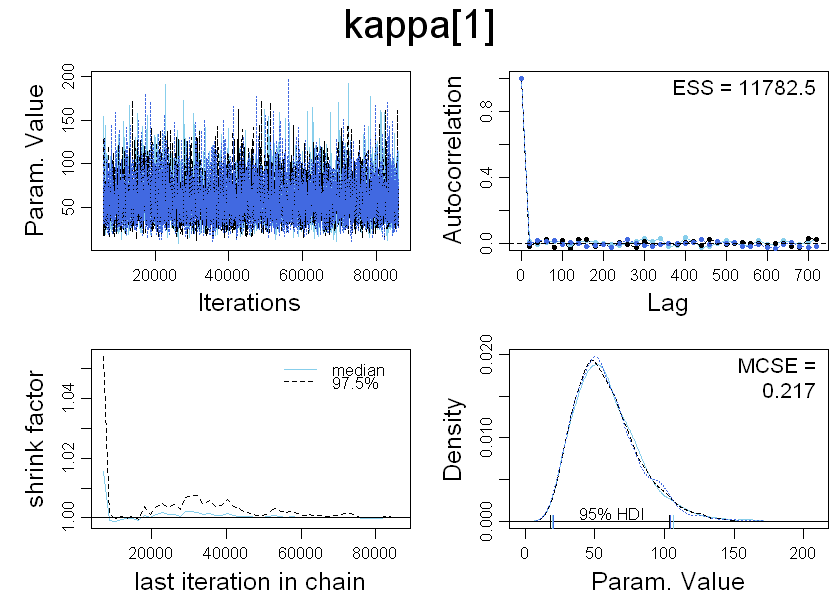

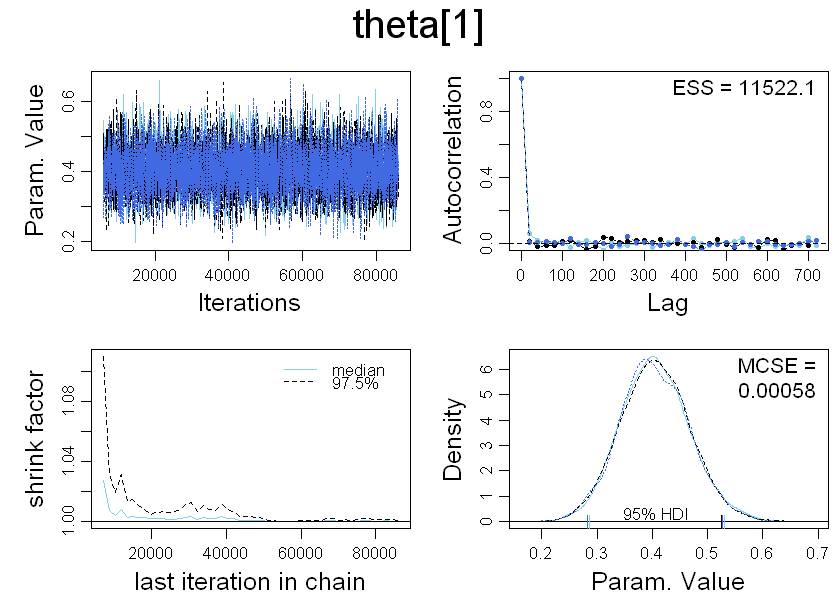

In [6]:

parameterNames = varnames(codaSamples) # get all parameter names
show(parameterNames)
for ( parName in c("mdlIdx","omega[1]","omega0","kappa[1]","theta[1]") ) { 
  diagMCMC(codaSamples , parName=parName)
}


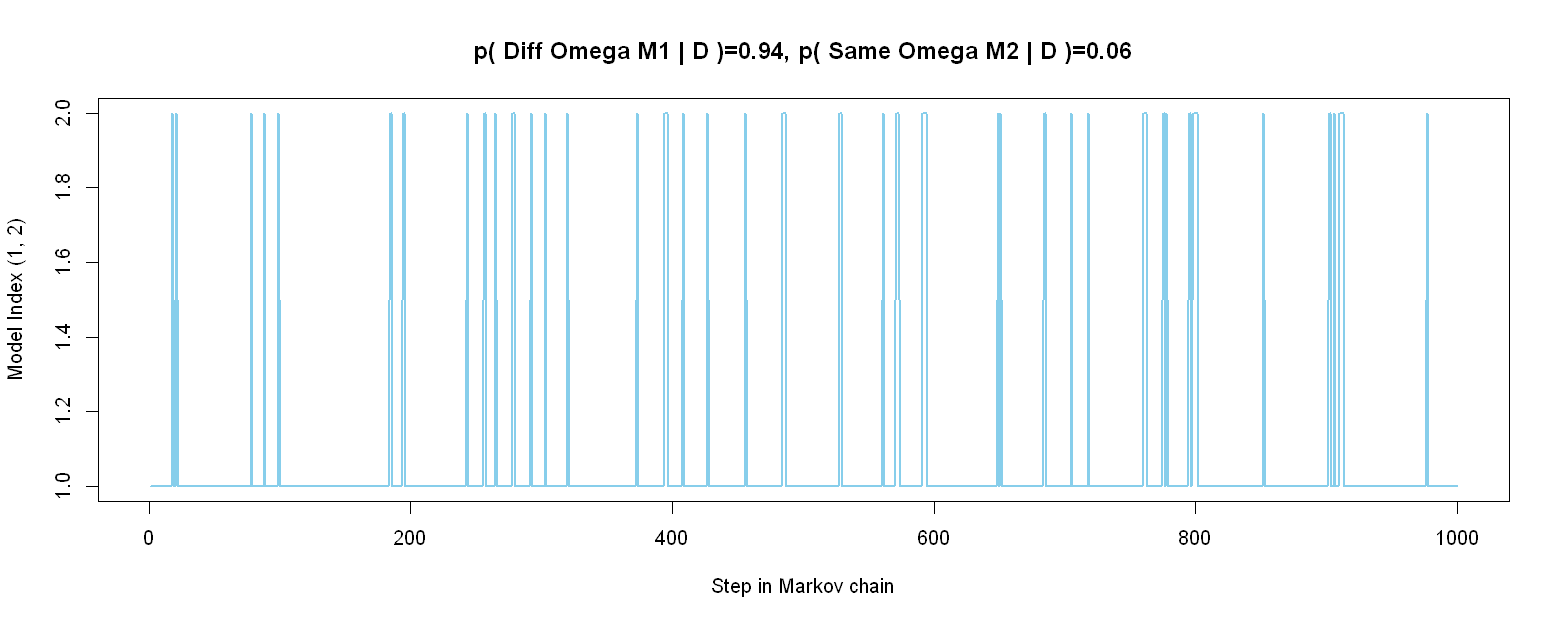

In [7]:

mcmcMat = as.matrix(codaSamples,chains=TRUE)

xLim=c(0.35,0.75)

# Display the model index
modelIdxSample = mcmcMat[, "mdlIdx" ]
pM1 = sum( modelIdxSample == 1 ) / length( modelIdxSample )
pM2 = 1 - pM1
string1 =paste("p( Diff Omega M1 | D )=",round(pM1,3),sep="")
string2 =paste("p( Same Omega M2 | D )=",round(pM2,3),sep="")
openGraph(10,4, mag=1.3)
nStepsToPlot = 1000
plot( 1:nStepsToPlot , modelIdxSample[1:nStepsToPlot] , type="l" , lwd=2 ,
      xlab="Step in Markov chain" , ylab="Model Index (1, 2)" ,
      main=paste(string1,", ",string2,sep="") , col="skyblue" )



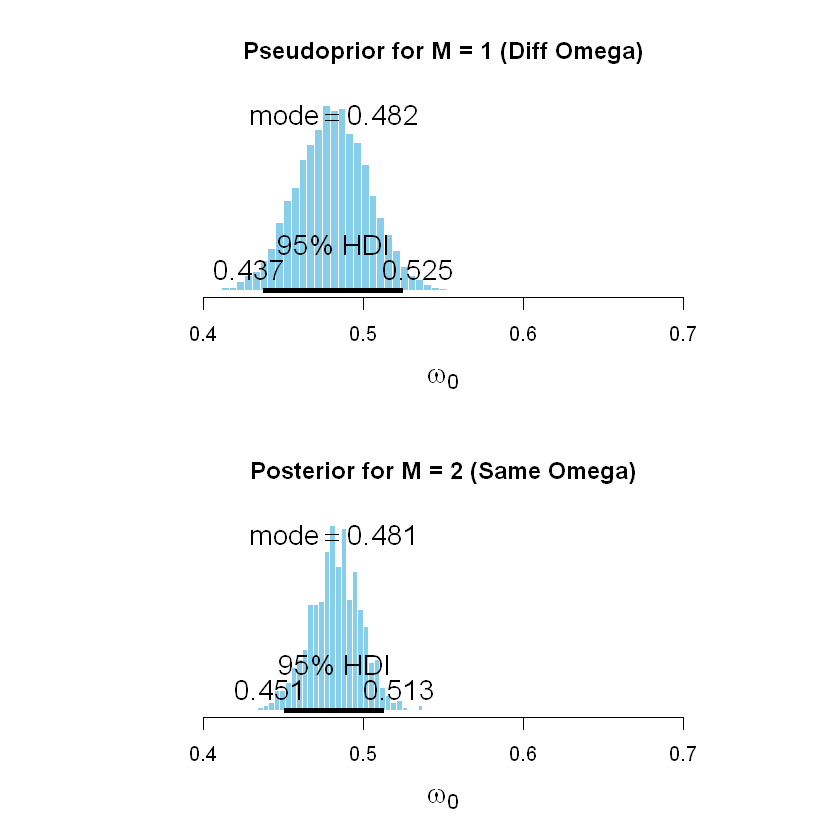

In [10]:
# Display the omega0 posterior
omega0sampleM1 = mcmcMat[, "omega0" ][ modelIdxSample == 1 ]
omega0sampleM2 = mcmcMat[, "omega0" ][ modelIdxSample == 2 ]
openGraph()
layout( matrix(1:2,nrow=2) )
results = plotPost( omega0sampleM1 , main="Pseudoprior for M = 1 (Diff Omega)" ,
      xlab=expression(omega[0]) , xlim=xLim )
results = plotPost( omega0sampleM2 , main="Posterior for M = 2 (Same Omega)"  ,
      xlab=expression(omega[0]) , xlim=xLim )

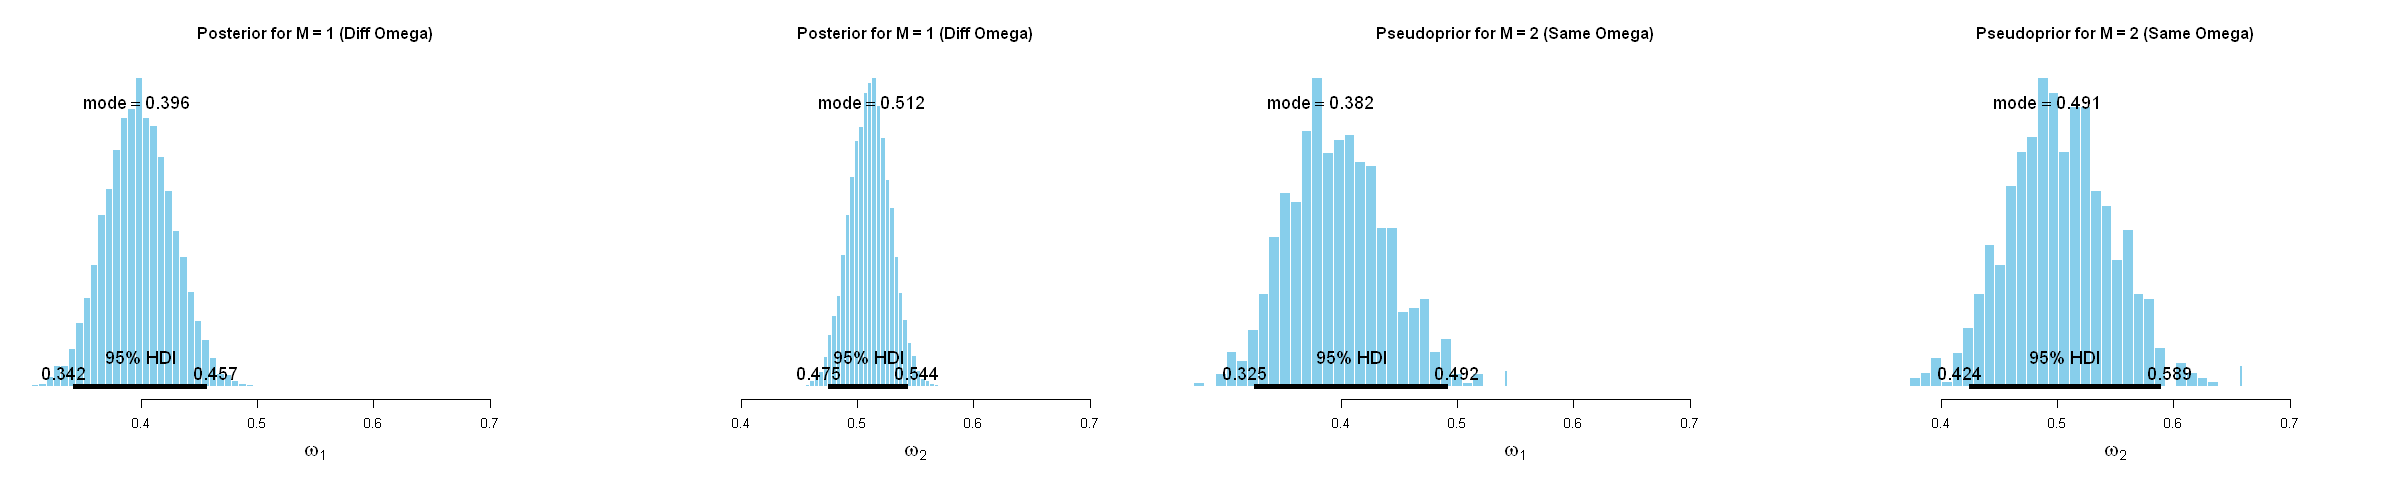

In [12]:

# Display the omega[j] posterior
omega1sampleM1 = mcmcMat[, "omega[1]" ][ modelIdxSample == 1 ]
omega2sampleM1 = mcmcMat[, "omega[2]" ][ modelIdxSample == 1 ]
omega1sampleM2 = mcmcMat[, "omega[1]" ][ modelIdxSample == 2 ]
omega2sampleM2 = mcmcMat[, "omega[2]" ][ modelIdxSample == 2 ]
openGraph(10,2, mag=2)
layout( matrix(1:4,nrow=1,byrow=T) )
results = plotPost( omega1sampleM1 , main="Posterior for M = 1 (Diff Omega)" ,
          xlab=expression(omega[1]) , xlim=xLim )
results = plotPost( omega2sampleM1 , main="Posterior for M = 1 (Diff Omega)" ,
          xlab=expression(omega[2]) , xlim=xLim )
results = plotPost( omega1sampleM2 , main="Pseudoprior for M = 2 (Same Omega)" ,
          xlab=expression(omega[1]) , xlim=xLim )
results = plotPost( omega2sampleM2 , main="Pseudoprior for M = 2 (Same Omega)" ,
          xlab=expression(omega[2]) , xlim=xLim )

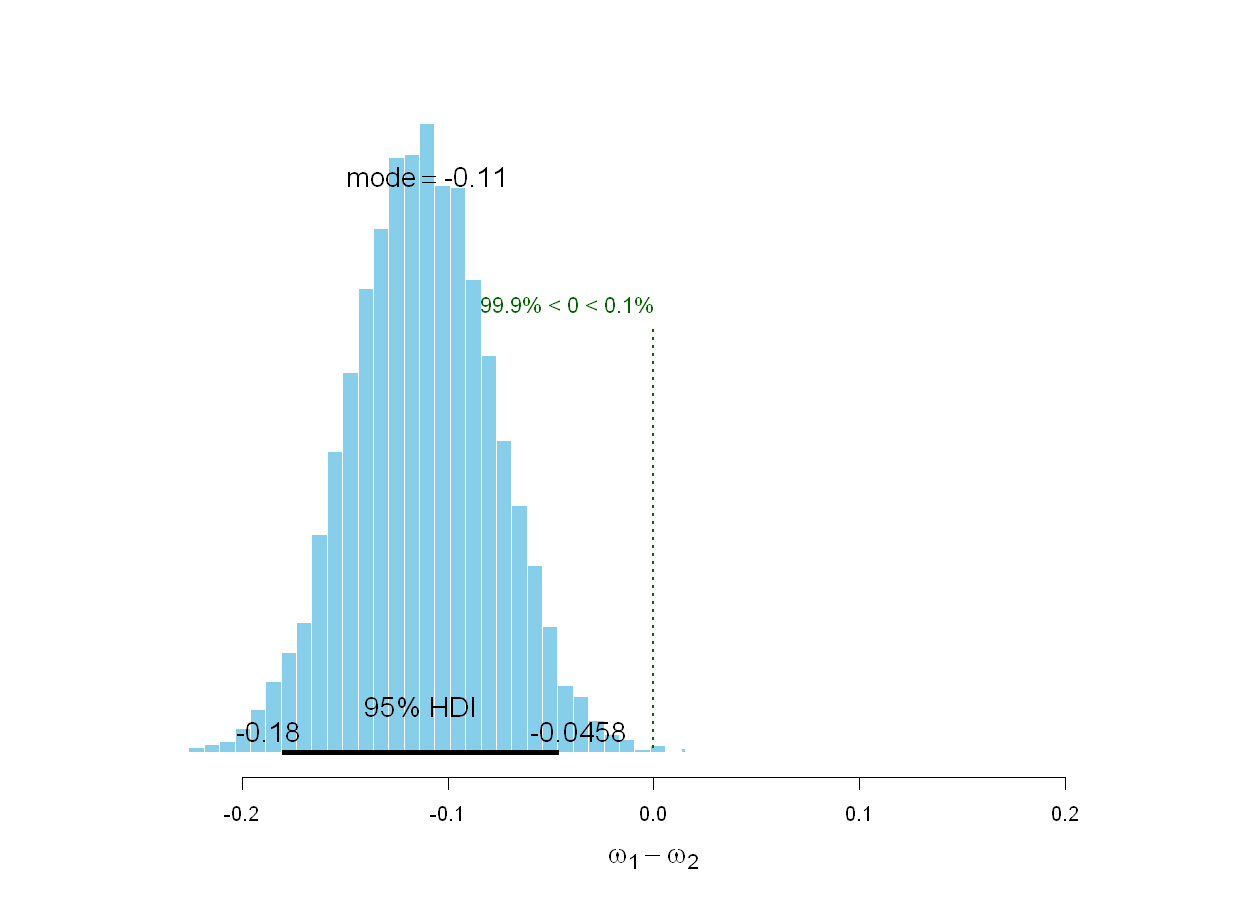

In [9]:
# Display the differences of omega[j]'s
omegaSample = rbind( omega1sampleM1 , omega2sampleM1)
openGraph(7,5,1.5)
xmin = -0.25
xmax = 0.25
for ( i in 1:1 ) {
    for ( j in (i+1):2 ) {
        results = plotPost( omegaSample[i,]-omegaSample[j,] , compVal=0.0 ,
                  xlab=bquote(omega[.(i)]-omega[.(j)]) ,
                  #breaks=unique( c( min(c(xmin,omegaSample[i,]-omegaSample[j,])),
                  #          seq(xmin,xmax,len=20),
                  #          max(c(xmax,omegaSample[i,]-omegaSample[j,])) )) ,
                  main="" , xlim=c(xmin,xmax) )
    }
}


In [11]:
dataList

$nCond
[1] 2

$nSubj
[1] 80

$CondOfSubj
 [1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[39] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[77] 2 2 2 2

$nTrlOfSubj
 [1] 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
[26] 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
[51] 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
[76] 20 20 20 20 20

$nCorrOfSubj
 [1]  8  8  8  6  7  9  8  9  9  8  5  8 10  9  8  7  8  8  9  8 10 12  9  7  8
[26] 10  9 11 13  7 12 16 12 13 11  8  7  9 11  5 12  6 12 11 12 11 12 10 11  6
[51] 10 12 11 13  9 11  9 10  8  8  6 12 13 11 14 11 11 10 10 11  8 14 10 11  7
[76] 15  9 10  9  6